## Salary Analysis

In [1]:
# import libraries
import ast

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

# load dataset
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# clean data
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

df['job_skills'] = df['job_skills'].apply(
    lambda x: ast.literal_eval(x) if pd.notna(x) else x
)

In [2]:
# filer only the US and drop the NaN value for salary_year_avg
df_us = df[df['job_country'] == 'United States'].dropna(subset=['salary_year_avg']).copy()

df_us.head()

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
92,Data Engineer,Remote - Data Engineer - Permanent - W2,Anywhere,via LinkedIn,Full-time,True,"Illinois, United States",2023-02-21 13:29:59,False,True,United States,year,120000.0,NaN,Apex Systems,"[sql, python]","{'programming': ['sql', 'python']}"
100,Data Scientist,"Data Scientist, Risk Data Mining - USDS","Mountain View, CA",via LinkedIn,Full-time,False,"California, United States",2023-07-31 13:01:18,False,True,United States,year,228222.0,NaN,TikTok,"[sql, r, python, express]","{'programming': ['sql', 'r', 'python'], 'webfr..."
109,Data Analyst,Senior Supply Chain Analytics Analyst,Anywhere,via Get.It,Full-time,True,"Illinois, United States",2023-10-12 13:02:19,False,True,United States,year,89000.0,NaN,Get It Recruit - Transportation,"[python, r, alteryx, tableau]","{'analyst_tools': ['alteryx', 'tableau'], 'pro..."
116,Data Scientist,Data Scientist,Anywhere,via LinkedIn,Full-time,True,"Texas, United States",2023-10-04 13:04:23,False,False,United States,year,114000.0,NaN,4 Corner Resources,"[r, python, sql, t-sql, hadoop, spark, tableau]","{'analyst_tools': ['tableau'], 'libraries': ['..."
146,Data Engineer,Data Engineer Graduate (Real Time Communicatio...,"Seattle, WA",via LinkedIn,Full-time,False,"California, United States",2023-10-21 13:06:16,False,True,United States,year,129500.0,NaN,ByteDance,"[golang, scala, python, java, hadoop, spark]","{'libraries': ['hadoop', 'spark'], 'programmin..."


In [3]:
# top 6 job_title by salary_year_avg
# make a list out of it

job_titles = df_us['job_title_short'].value_counts().index[:6].to_list()

job_titles

['Data Scientist',
 'Data Analyst',
 'Data Engineer',
 'Senior Data Scientist',
 'Senior Data Engineer',
 'Senior Data Analyst']

In [4]:
# filter out the df_us by job_titles
df_us_top6 = df_us[df_us['job_title_short'].isin(job_titles)]

df_us_top6.head()

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
92,Data Engineer,Remote - Data Engineer - Permanent - W2,Anywhere,via LinkedIn,Full-time,True,"Illinois, United States",2023-02-21 13:29:59,False,True,United States,year,120000.0,NaN,Apex Systems,"[sql, python]","{'programming': ['sql', 'python']}"
100,Data Scientist,"Data Scientist, Risk Data Mining - USDS","Mountain View, CA",via LinkedIn,Full-time,False,"California, United States",2023-07-31 13:01:18,False,True,United States,year,228222.0,NaN,TikTok,"[sql, r, python, express]","{'programming': ['sql', 'r', 'python'], 'webfr..."
109,Data Analyst,Senior Supply Chain Analytics Analyst,Anywhere,via Get.It,Full-time,True,"Illinois, United States",2023-10-12 13:02:19,False,True,United States,year,89000.0,NaN,Get It Recruit - Transportation,"[python, r, alteryx, tableau]","{'analyst_tools': ['alteryx', 'tableau'], 'pro..."
116,Data Scientist,Data Scientist,Anywhere,via LinkedIn,Full-time,True,"Texas, United States",2023-10-04 13:04:23,False,False,United States,year,114000.0,NaN,4 Corner Resources,"[r, python, sql, t-sql, hadoop, spark, tableau]","{'analyst_tools': ['tableau'], 'libraries': ['..."
146,Data Engineer,Data Engineer Graduate (Real Time Communicatio...,"Seattle, WA",via LinkedIn,Full-time,False,"California, United States",2023-10-21 13:06:16,False,True,United States,year,129500.0,NaN,ByteDance,"[golang, scala, python, java, hadoop, spark]","{'libraries': ['hadoop', 'spark'], 'programmin..."


In [5]:
# sort job_title_sort by median salary
# and extract the index only for plot purposes
job_title_sorted = df_us_top6.groupby('job_title_short')['salary_year_avg'].median().sort_values(ascending=False).index.to_list()

job_title_sorted

['Senior Data Scientist',
 'Senior Data Engineer',
 'Data Scientist',
 'Data Engineer',
 'Senior Data Analyst',
 'Data Analyst']

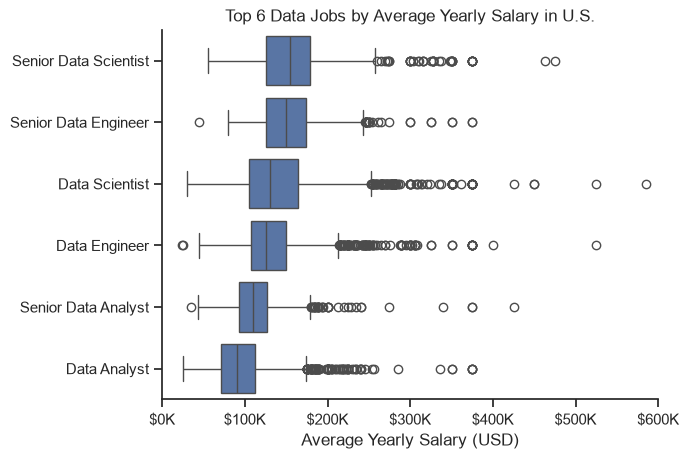

In [12]:
# Plot salary distribution by job title
sns.boxplot(
    data=df_us_top6,
    x='salary_year_avg',
    y='job_title_short',
    order=job_title_sorted
)

sns.set_theme(style='ticks')
sns.despine()

plt.title('Top 6 Data Jobs by Average Yearly Salary in U.S.')
plt.xlabel('Average Yearly Salary (USD)')
plt.ylabel('')
plt.xlim(0, 600000)

# Format x-axis
ticks_x = plt.FuncFormatter(lambda x, _: f'${int(x / 1000)}K')
plt.gca().xaxis.set_major_formatter(ticks_x)

plt.show()

## Median Salary Vs. Skill for Data Engineer in United States

In [7]:
# filter only United States and Data Engineer
df_de_us = df[(df['job_country'] == 'United States') & (df['job_title_short'] == 'Data Engineer')].copy()

# drop the NaN value for salary_year_avg
df_de_us = df_de_us.dropna(subset=['salary_year_avg'])

df_de_us.head()

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
92,Data Engineer,Remote - Data Engineer - Permanent - W2,Anywhere,via LinkedIn,Full-time,True,"Illinois, United States",2023-02-21 13:29:59,False,True,United States,year,120000.0,NaN,Apex Systems,"[sql, python]","{'programming': ['sql', 'python']}"
146,Data Engineer,Data Engineer Graduate (Real Time Communicatio...,"Seattle, WA",via LinkedIn,Full-time,False,"California, United States",2023-10-21 13:06:16,False,True,United States,year,129500.0,NaN,ByteDance,"[golang, scala, python, java, hadoop, spark]","{'libraries': ['hadoop', 'spark'], 'programmin..."
307,Data Engineer,Data Engineer,"Austin, TX",via LinkedIn,Full-time,False,"New York, United States",2023-10-03 13:05:31,False,False,United States,year,185000.0,NaN,hackajob,"[nosql, sql]","{'programming': ['nosql', 'sql']}"
339,Data Engineer,Global Market Leading Energy Firm - Staff Data...,United States,via LinkedIn,Full-time,False,"California, United States",2023-09-22 13:07:57,False,False,United States,year,195000.0,NaN,Xcede,NaN,NaN
380,Data Engineer,Snaplogic Data Engineer,"Durham, NC",via LinkedIn,Full-time,False,"Illinois, United States",2023-08-16 13:26:21,True,False,United States,year,97500.0,NaN,KTek Resourcing,"[sql, python]","{'programming': ['sql', 'python']}"


In [8]:
# explode job_skills to count it later
df_de_us_explode = df_de_us.explode('job_skills')

df_de_us_explode[['salary_year_avg', 'job_skills']].head()

,salary_year_avg,job_skills
92,120000.0,sql
92,120000.0,python
146,129500.0,golang
146,129500.0,scala
146,129500.0,python


In [9]:
# group by job_skills
# filter the top median
df_top_pay = df_de_us_explode.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='median', ascending=False)

# top 10 by median
df_top_pay = df_top_pay.head(10)

df_top_pay

,count,median
job_skills,,
mongo,78,208114.0
vue,1,200000.0
solidity,1,192500.0
node,24,190000.0
ggplot2,2,176250.0
macos,2,172000.0
clojure,2,170866.5
atlassian,18,169860.0
rust,7,165000.0


In [10]:
# group by, and top skills
df_top_skills = df_de_us_explode.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by='count', ascending=False)

# top 10 by skills, and sort it by median
df_top_skills = df_top_skills.head(10).sort_values(by='median', ascending=False)

df_top_skills

,count,median
job_skills,,
kafka,536,145000.00000
nosql,519,140000.00000
spark,968,137410.15625
java,732,137000.00000
redshift,514,135000.00000
aws,1313,131000.00000
snowflake,765,130700.00000
python,2007,127794.50000
sql,2110,125000.00000


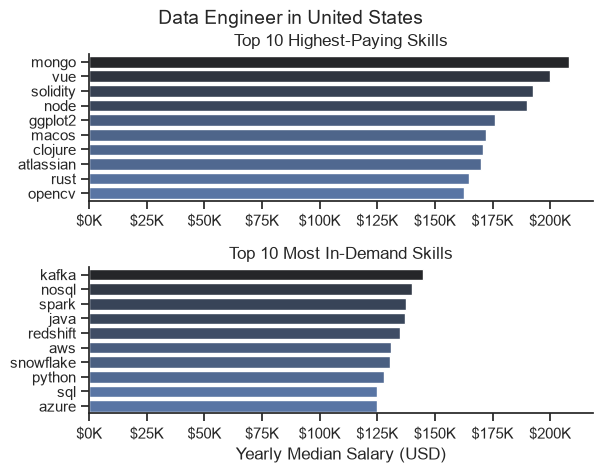

In [13]:
# Plot salary comparison
fig, ax = plt.subplots(2, 1)

# Plot top 10 highest-paying skills
sns.barplot(
    data=df_top_pay,
    x='median',
    y=df_top_pay.index,
    ax=ax[0],
    hue='median',
    palette='dark:b_r'
)

# Plot top 10 most in-demand skills
sns.barplot(
    data=df_top_skills,
    x='median',
    y=df_top_skills.index,
    ax=ax[1],
    hue='median',
    palette='dark:b_r'
)

sns.despine()

fig.suptitle('Data Engineer in United States', fontsize=14)
fig.tight_layout()

ax[0].set_title('Top 10 Highest-Paying Skills')
ax[0].legend().remove()
ax[0].set_xlabel('')
ax[0].set_ylabel('')
ax[0].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${int(x / 1000)}K')
)

ax[1].set_title('Top 10 Most In-Demand Skills')
ax[1].legend().remove()
ax[1].set_xlabel('Yearly Median Salary (USD)')
ax[1].set_ylabel('')
ax[1].set_xlim(ax[0].get_xlim())
ax[1].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${int(x / 1000)}K')
)

plt.show()